### **Assignment 2** — Real Estate Price Prediction (Feature Engineering)
Objective: Predict house prices using Linear Regression with extensive feature engineering

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#from google.colab import files                                   #Comment out if you ar runnin locally
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [ ]:
uploaded = files.upload()  #Comment out if you ar runnin locally

Saving Housing.csv.csv to Housing.csv.csv


Data Exploration

In [4]:
df = pd.read_csv('Housing.csv.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
print(df.shape)
df.info()
df.describe()
df.isnull().sum()


(545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [6]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


Handle Missing Values

For numerical columns, fill with mean.
For categorical columns, fill with mode.

In [7]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Correation Matrix

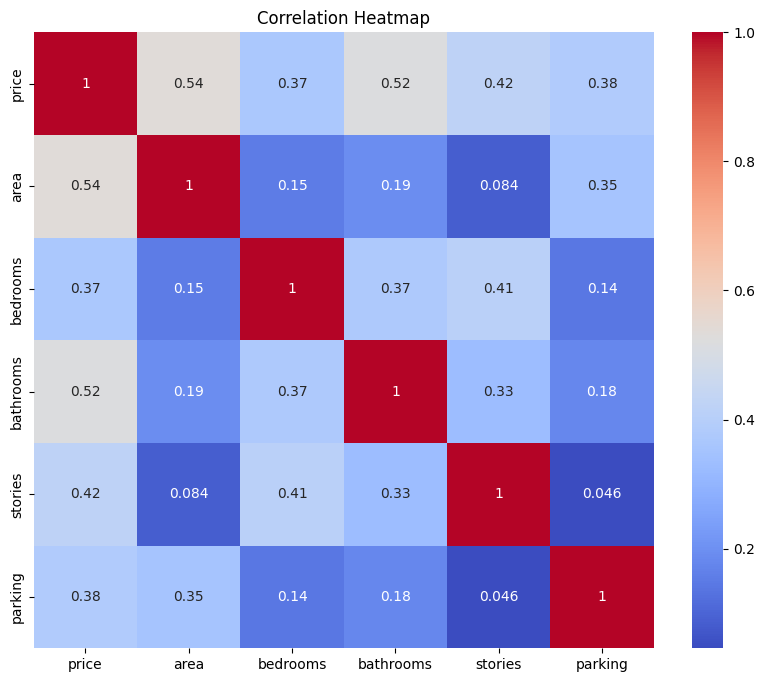

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Pair Plot

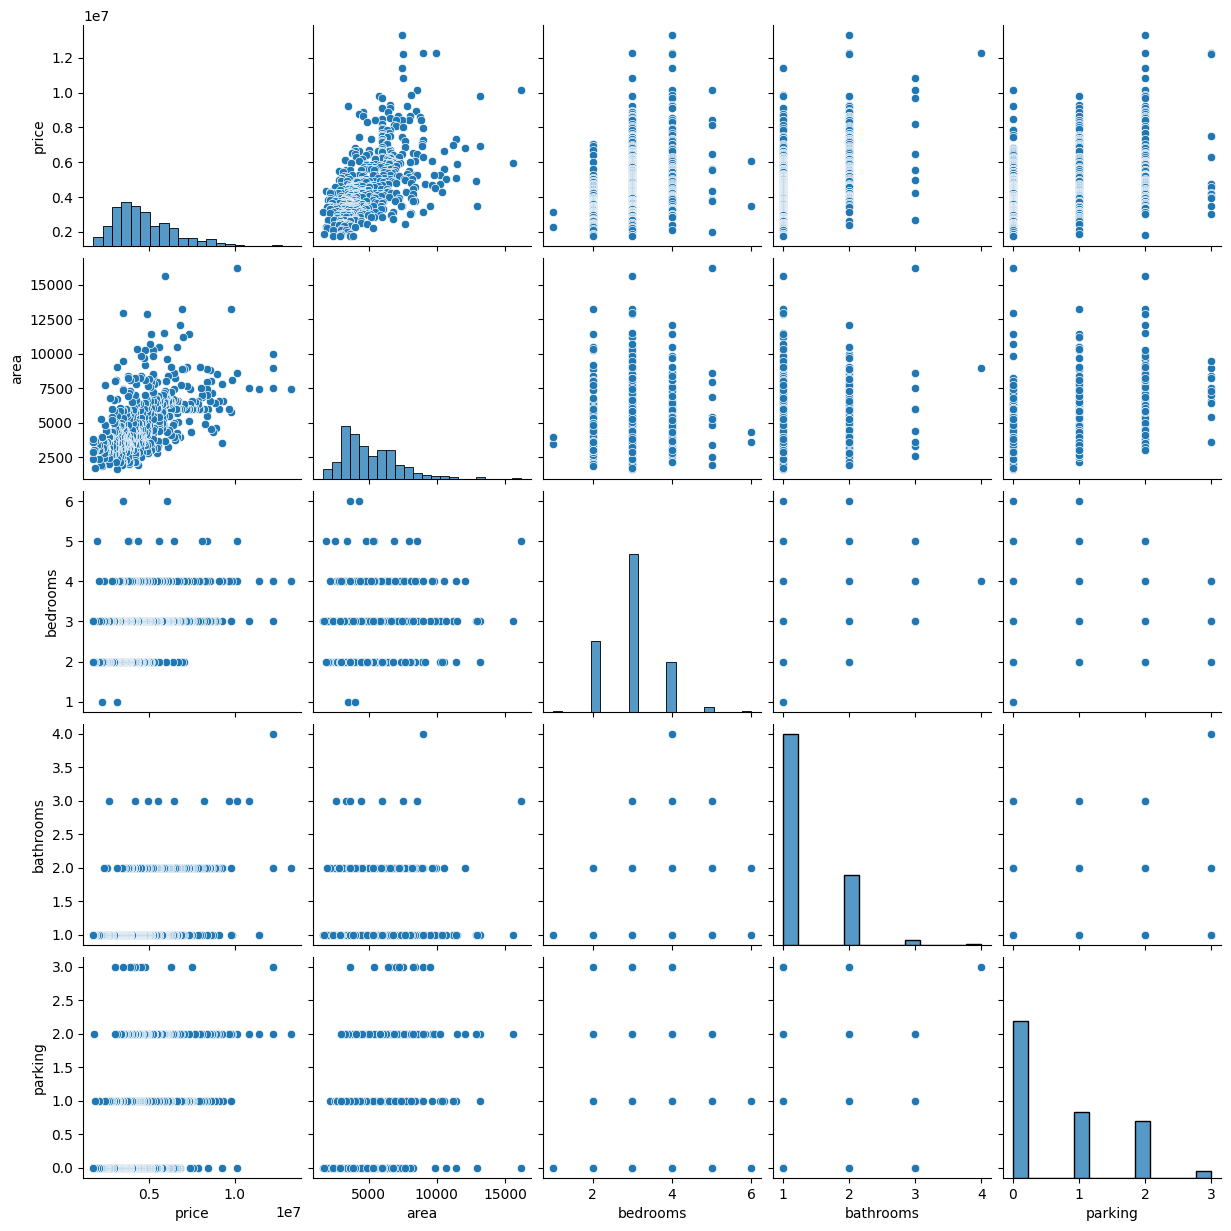

In [9]:
selected_cols = ['price']

for col in ['area', 'bedrooms', 'bathrooms', 'parking']:
    if col in df.columns:
        selected_cols.append(col)

sns.pairplot(df[selected_cols])
plt.show()

One-Hot Encoding

In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


Separate Features and Target

In [11]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

Detect Multicollinearity Using VIF

In [13]:
X = df_encoded.drop('price', axis=1).astype(int)
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

                            Feature        VIF
0                             const  33.384521
1                              area   1.325250
2                          bedrooms   1.369477
3                         bathrooms   1.286621
4                           stories   1.478055
5                           parking   1.212837
6                      mainroad_yes   1.172728
7                     guestroom_yes   1.212838
8                      basement_yes   1.323050
9               hotwaterheating_yes   1.041506
10              airconditioning_yes   1.211840
11                     prefarea_yes   1.149196
12  furnishingstatus_semi-furnished   1.578233
13     furnishingstatus_unfurnished   1.674139


Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Simple Linear Regression

In [15]:
X_simple = df[['area']]
y_simple = df['price']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

simple_pred = simple_model.predict(X_test_s)

In [16]:
mae_simple = mean_absolute_error(y_test_s, simple_pred)
rmse_simple = np.sqrt(mean_squared_error(y_test_s, simple_pred))
r2_simple = r2_score(y_test_s, simple_pred)

print("Simple Linear Regression")
print("MAE:", mae_simple)
print("RMSE:", rmse_simple)
print("R2:", r2_simple)

Simple Linear Regression
MAE: 1474748.1337969352
RMSE: 1917103.7021424233
R2: 0.27287851871974644


Multiple Linear Regression

In [18]:
multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

multiple_pred = multiple_model.predict(X_test)

In [19]:
mae_multiple = mean_absolute_error(y_test, multiple_pred)
rmse_multiple = np.sqrt(mean_squared_error(y_test, multiple_pred))
r2_multiple = r2_score(y_test, multiple_pred)

print("\nMultiple Linear Regression")
print("MAE:", mae_multiple)
print("RMSE:", rmse_multiple)
print("R2:", r2_multiple)


Multiple Linear Regression
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R2: 0.6529242642153184


In [20]:
comparison = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression'],
    'MAE': [mae_simple, mae_multiple],
    'RMSE': [rmse_simple, rmse_multiple],
    'R2': [r2_simple, r2_multiple]
})

comparison

,Model,MAE,RMSE,R2
0,Simple Linear Regression,1.474748e+06,1.917104e+06,0.272879
1,Multiple Linear Regression,9.700434e+05,1.324507e+06,0.652924


Residual Plot

Residual = actual - predicted

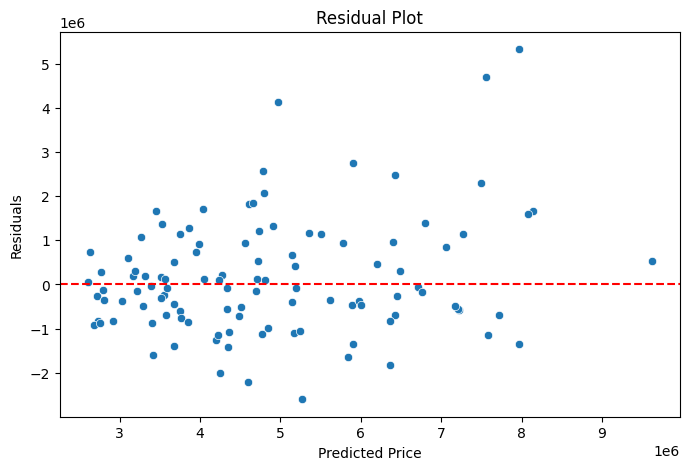

In [21]:
residuals = y_test - multiple_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=multiple_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

Predicted vs Actual Plot

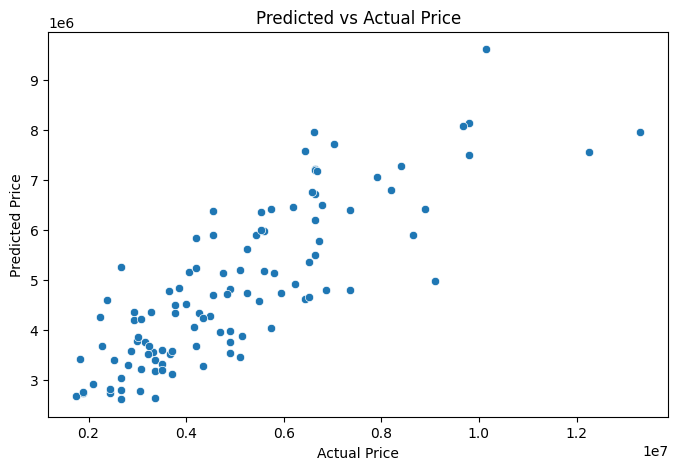

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=multiple_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Price')
plt.show()

Feature Importance Using Coefficients

In [23]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': multiple_model.coef_
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
coef_df.head(10)

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05
1,bedrooms,7.677870e+04


In [24]:
print(df.corr(numeric_only=True)['price'].sort_values(ascending=False))

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64
